In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import skew, kurtosis

import smogn
import joblib
import json

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Step 1 — Data Collection

In [2]:
df = pd.read_csv('data.csv')

print('\n First 5 Rows:')
print(df.head())
print(f'\nDataset shape: {df.shape}')


 First 5 Rows:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2793718          2  2016-06-08 07:36:19  2016-06-08 07:53:39   
1  id3485529          2  2016-04-03 12:58:11  2016-04-03 13:11:58   
2  id1816614          2  2016-06-05 02:49:13  2016-06-05 02:59:27   
3  id1050851          2  2016-05-05 17:18:27  2016-05-05 17:32:54   
4  id0140657          1  2016-05-12 17:43:38  2016-05-12 19:06:25   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.985611        40.735943         -73.980331   
1                1        -73.978394        40.764351         -73.991623   
2                5        -73.989059        40.744389         -73.973381   
3                2        -73.990326        40.731136         -73.991264   
4                4        -73.789497        40.646675         -73.987137   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.760468                  N           1040  


In [3]:
print('\n Basic Statistics:')
print(df.describe())


 Basic Statistics:
          vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count  72932.000000     72932.000000      72932.000000     72932.000000   
mean       1.535828         1.672476        -73.973384        40.750846   
std        0.498718         1.320324          0.042220         0.036419   
min        1.000000         0.000000        -77.896019        35.310307   
25%        1.000000         1.000000        -73.991928        40.737370   
50%        2.000000         1.000000        -73.981773        40.754143   
75%        2.000000         2.000000        -73.967186        40.768430   
max        2.000000         6.000000        -72.074333        41.033432   

       dropoff_longitude  dropoff_latitude  trip_duration  
count       72932.000000      72932.000000   72932.000000  
mean          -73.973484         40.751657     968.280069  
std             0.045316          0.040621    3342.427961  
min           -79.817978         35.173546       2.000000  
25% 

In [4]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

duration_pd = df[['trip_duration']].copy()

hour_counts = (
    df.assign(hour=df['pickup_datetime'].dt.hour)
      .groupby('hour', as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
dow_counts = (
    df.assign(day=df['pickup_datetime'].dt.dayofweek.map(day_map))
      .groupby('day', as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)
dow_counts['day'] = pd.Categorical(dow_counts['day'],
                                  categories=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
                                  ordered=True)
dow_counts = dow_counts.sort_values('day')

pax_counts = (
    df.groupby('passenger_count', as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

vendor_pd = (
    df.groupby('vendor_id', as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

coords_pd = df[['pickup_longitude', 'pickup_latitude']].dropna().sample(
    n=min(50000, len(df)), random_state=42
)

print(' EDA aggregations ready')

 EDA aggregations ready


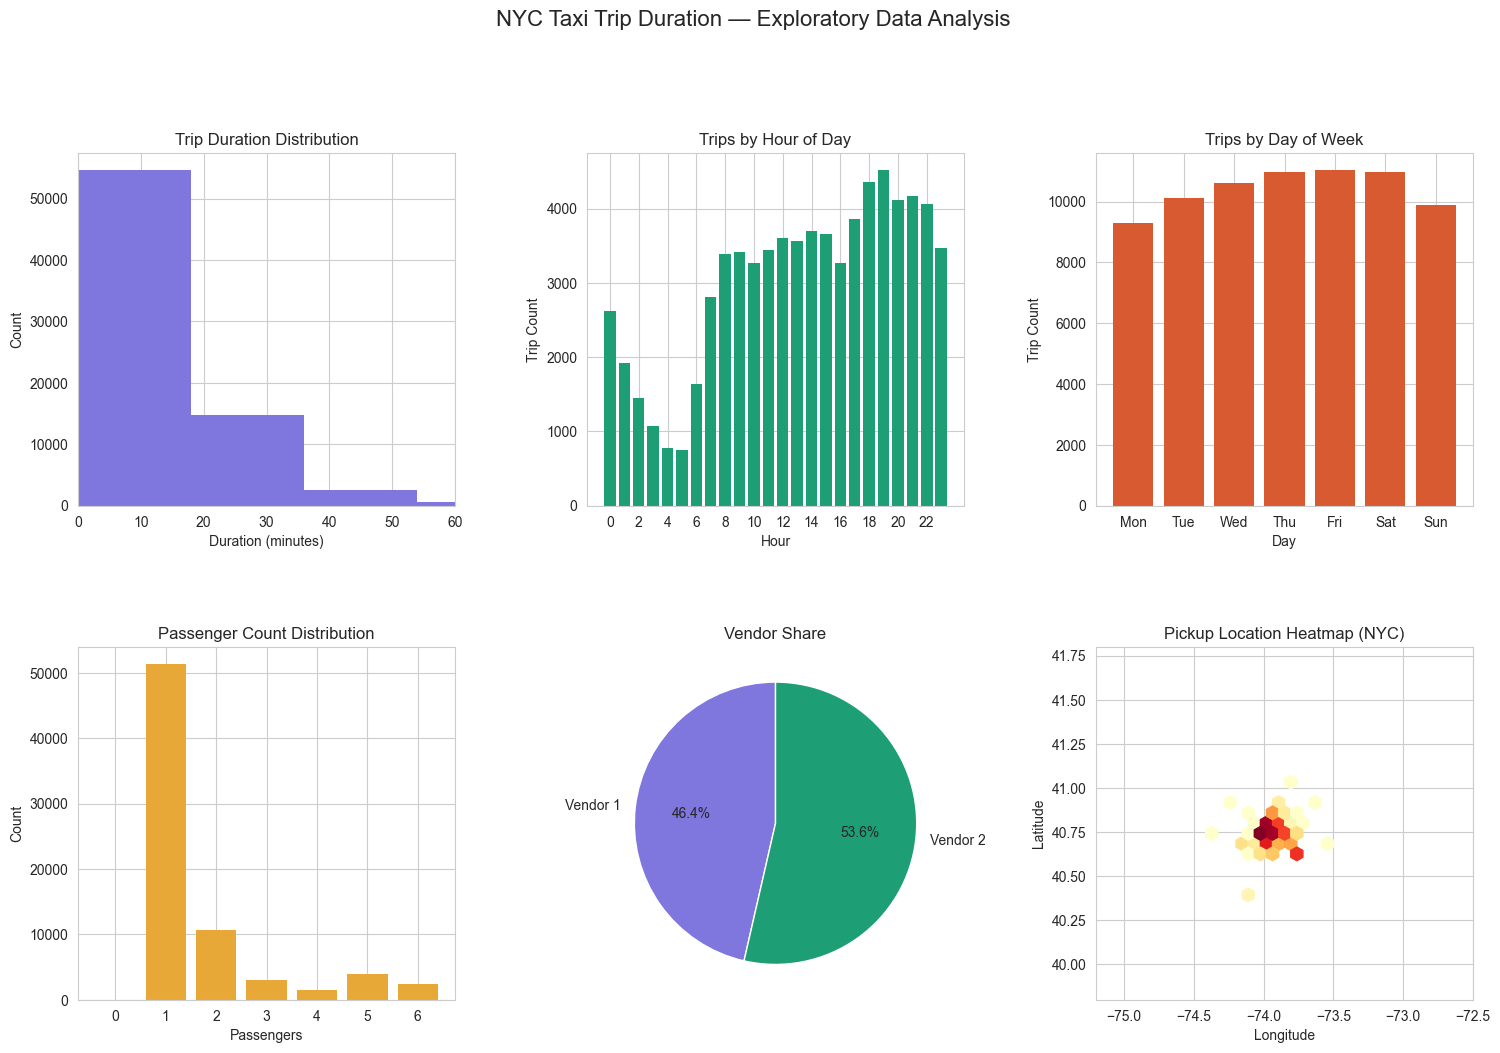

 Saved: plots/eda_plots.png


In [5]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("NYC Taxi Trip Duration — Exploratory Data Analysis", fontsize=16, y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(duration_pd["trip_duration"] / 60, bins=80, color="#7F77DD", edgecolor="none")
ax1.set_title("Trip Duration Distribution")
ax1.set_xlabel("Duration (minutes)")
ax1.set_ylabel("Count")
ax1.set_xlim(0, 60) 

ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(hour_counts["hour"], hour_counts["count"], color="#1D9E75", edgecolor="none")
ax2.set_title("Trips by Hour of Day")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Trip Count")
ax2.set_xticks(range(0, 24, 2))

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(dow_counts["day"], dow_counts["count"], color="#D85A30", edgecolor="none")
ax3.set_title("Trips by Day of Week")
ax3.set_xlabel("Day")
ax3.set_ylabel("Trip Count")

ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(pax_counts["passenger_count"].astype(str), pax_counts["count"],
        color="#E8A838", edgecolor="none")
ax4.set_title("Passenger Count Distribution")
ax4.set_xlabel("Passengers")
ax4.set_ylabel("Count")

ax5 = fig.add_subplot(gs[1, 1])
ax5.pie(vendor_pd["count"],
        labels=[f"Vendor {v}" for v in vendor_pd["vendor_id"]],
        autopct="%1.1f%%",
        colors=["#7F77DD", "#1D9E75"],
        startangle=90)
ax5.set_title("Vendor Share")

ax6 = fig.add_subplot(gs[1, 2])
ax6.hexbin(coords_pd["pickup_longitude"], coords_pd["pickup_latitude"],
                gridsize=50, cmap="YlOrRd", bins="log")
ax6.set_title("Pickup Location Heatmap (NYC)")
ax6.set_xlabel("Longitude")
ax6.set_ylabel("Latitude")
ax6.set_xlim(-75.20, -72.50)
ax6.set_ylim(39.80, 41.80)

plt.savefig("plots/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(' Saved: plots/eda_plots.png')

# Step 2 — Data Tidying & Cleaning

In [6]:
print(' Missing Values per Column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
has_missing = missing_df[missing_df['Missing Count'] > 0]
if len(has_missing) == 0:
    print('  No missing values found!')
else:
    print(has_missing)

 Missing Values per Column:
  No missing values found!


In [7]:
before = len(df)
df = df.drop_duplicates()
print(f' Duplicates removed : {before - len(df)}')
print(f'   Rows remaining     : {len(df):,}')

 Duplicates removed : 0
   Rows remaining     : 72,932


In [8]:
df['pickup_datetime']  = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
print(' Datetime columns converted:')
print(df[['pickup_datetime', 'dropoff_datetime']].dtypes.to_string())

 Datetime columns converted:
pickup_datetime     datetime64[ns]
dropoff_datetime    datetime64[ns]


In [9]:
print(f'Rows before duration filtering : {len(df):,}')
df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 10800)]
print(f'Rows after duration filtering  : {len(df):,}')
print(f'Rows removed                   : {before - len(df):,}')

Rows before duration filtering : 72,932
Rows after duration filtering  : 72,347
Rows removed                   : 585


In [10]:
print(f'Rows before GPS filtering : {len(df):,}')
df = df[
    (df['pickup_latitude'].between(40.5, 40.9))  &
    (df['pickup_longitude'].between(-74.3, -73.6)) &
    (df['dropoff_latitude'].between(40.5, 40.9))  &
    (df['dropoff_longitude'].between(-74.3, -73.6))
]
print(f'Rows after GPS filtering  : {len(df):,}')

Rows before GPS filtering : 72,347
Rows after GPS filtering  : 72,294


In [11]:
print('Passenger count before fixing:')
print(df['passenger_count'].value_counts().sort_index().to_string())
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
print(f'\n Rows after fixing: {len(df):,}')

Passenger count before fixing:
passenger_count
0        1
1    50950
2    10551
3     3013
4     1467
5     3855
6     2457

 Rows after fixing: 72,293


In [12]:
pivot = df.pivot_table(
    values='trip_duration',
    index='vendor_id',
    columns='passenger_count',
    aggfunc='mean'
).round(1)
print(pivot)

passenger_count      1      2      3       4      5      6
vendor_id                                                 
1                815.1  930.9  919.0  1021.0  833.5  628.4
2                847.7  857.4  814.4   825.7  853.3  834.4


# Step 3 — Feature Extraction

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['haversine_dist'] = haversine(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
df = df[df['haversine_dist'] > 0.05]
print(' haversine_dist extracted')
print(df['haversine_dist'].describe().round(3).to_string())

 haversine_dist extracted
count    71971.000
mean         3.453
std          3.872
min          0.051
25%          1.256
50%          2.107
75%          3.902
max         35.593


In [ ]:
df['manhattan_dist'] = (
    (df['dropoff_latitude']  - df['pickup_latitude']).abs() +
    (df['dropoff_longitude'] - df['pickup_longitude']).abs()
)
print(' manhattan_dist extracted')

df['bearing'] = np.arctan2(
    df['dropoff_longitude'] - df['pickup_longitude'],
    df['dropoff_latitude']  - df['pickup_latitude']
)
print(' bearing extracted')

 manhattan_dist extracted
 bearing extracted


In [15]:
df['pickup_hour']      = df['pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month']     = df['pickup_datetime'].dt.month
df['pickup_day']       = df['pickup_datetime'].dt.day
df['is_weekend']       = (df['pickup_dayofweek'] >= 5).astype(int)
df['is_rush_hour']     = df['pickup_hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_night']         = (df['pickup_hour'].isin(range(22, 24)) |
                            df['pickup_hour'].isin(range(0, 6))).astype(int)

df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)
df['log_duration']       = np.log1p(df['trip_duration'])

print(' Temporal features + encoding done')
print(f'\n   Clean dataset shape: {df.shape}')

 Temporal features + encoding done

   Clean dataset shape: (71971, 22)


# Step 4 — Feature Selection

In [16]:
FEATURES = [
    'vendor_id', 'passenger_count', 'store_and_fwd_flag',
    'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day',
    'is_weekend', 'is_rush_hour', 'is_night',
    'haversine_dist', 'manhattan_dist', 'bearing',
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude'
]

X = df[FEATURES].copy()
y = df['log_duration'].copy()

print(f' Feature matrix : {X.shape}')
print(f'   Target        : log_duration')
print(f'   Features ({len(FEATURES)}): {FEATURES}')

 Feature matrix : (71971, 17)
   Target        : log_duration
   Features (17): ['vendor_id', 'passenger_count', 'store_and_fwd_flag', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day', 'is_weekend', 'is_rush_hour', 'is_night', 'haversine_dist', 'manhattan_dist', 'bearing', 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']


In [17]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train_raw.shape[0]:,}  |  Test size: {X_test_raw.shape[0]:,}')

Train size: 57,576  |  Test size: 14,395


In [18]:
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train_raw, y_train_raw)

kbest_df = pd.DataFrame({
    'Feature' : FEATURES,
    'F-Score' : selector.scores_,
    'P-Value' : selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print(' Method 1 — SelectKBest (F-Regression):')
print(kbest_df.round(4).to_string(index=False))

top_kbest = kbest_df[kbest_df['P-Value'] < 0.05]['Feature'].tolist()
print(f'\n Significant features (p<0.05): {top_kbest}')

 Method 1 — SelectKBest (F-Regression):
           Feature    F-Score  P-Value
    haversine_dist 46628.2675   0.0000
    manhattan_dist 41365.3350   0.0000
  pickup_longitude  3826.0663   0.0000
   pickup_latitude  2449.5287   0.0000
 dropoff_longitude  1778.9869   0.0000
  dropoff_latitude  1775.4270   0.0000
        is_weekend   212.1614   0.0000
      pickup_month   172.4961   0.0000
       pickup_hour    98.0456   0.0000
          is_night    97.4786   0.0000
  pickup_dayofweek    64.6392   0.0000
store_and_fwd_flag    18.8002   0.0000
   passenger_count    18.6927   0.0000
        pickup_day     2.9829   0.0842
         vendor_id     1.3722   0.2414
      is_rush_hour     0.6517   0.4195
           bearing     0.0108   0.9173

 Significant features (p<0.05): ['haversine_dist', 'manhattan_dist', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'is_weekend', 'pickup_month', 'pickup_hour', 'is_night', 'pickup_dayofweek', 'store_and_fwd_flag', 'passenge

In [19]:
FEATURES_NO_HAVER = [f for f in FEATURES if f not in ('haversine_dist', 'manhattan_dist')]

rf_sel = RandomForestRegressor(n_estimators=50, max_depth=10,
                                random_state=42, n_jobs=-1)
rf_sel.fit(X_train_raw[FEATURES_NO_HAVER], y_train_raw)

rf_imp_df = pd.DataFrame({
    'Feature'    : FEATURES_NO_HAVER,
    'Importance' : rf_sel.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(' Method 2 — Random Forest Feature Importance (excl. haversine_dist & manhattan_dist):')
print(rf_imp_df.round(4).to_string(index=False))

top_rf = ['haversine_dist', 'manhattan_dist'] + rf_imp_df.head(12)['Feature'].tolist()
print(f'\n Selected features (top 12 + haversine + manhattan): {top_rf}')

 Method 2 — Random Forest Feature Importance (excl. haversine_dist & manhattan_dist):
           Feature  Importance
   pickup_latitude      0.2846
  pickup_longitude      0.2648
  dropoff_latitude      0.1997
 dropoff_longitude      0.1821
       pickup_hour      0.0372
           bearing      0.0180
          is_night      0.0034
  pickup_dayofweek      0.0030
        pickup_day      0.0019
      pickup_month      0.0015
        is_weekend      0.0014
   passenger_count      0.0010
      is_rush_hour      0.0009
         vendor_id      0.0002
store_and_fwd_flag      0.0002

 Selected features (top 12 + haversine + manhattan): ['haversine_dist', 'manhattan_dist', 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'pickup_hour', 'bearing', 'is_night', 'pickup_dayofweek', 'pickup_day', 'pickup_month', 'is_weekend', 'passenger_count']


In [20]:
comp = pd.DataFrame({'Feature': FEATURES})
comp['Rank_KBest']     = comp['Feature'].apply(
    lambda f: kbest_df[kbest_df['Feature']==f].index[0]+1)
comp['Rank_RF']        = comp['Feature'].apply(
    lambda f: rf_imp_df[rf_imp_df['Feature']==f].index[0]+1
    if f in rf_imp_df['Feature'].values else 0)  
comp['Selected_KBest'] = comp['Feature'].isin(top_kbest).map({True:'✅', False:'❌'})
comp['Selected_RF']    = comp['Feature'].isin(top_rf).map({True:'✅', False:'❌'})
comp = comp.sort_values('Rank_RF').reset_index(drop=True)

print(' Feature Selection Comparison:')
print(comp.to_string(index=False))

selected_features = [f for f in FEATURES if f in top_kbest or f in top_rf]
print(f'\n Final Selected Features ({len(selected_features)}): {selected_features}')

 Feature Selection Comparison:
           Feature  Rank_KBest  Rank_RF Selected_KBest Selected_RF
    haversine_dist           1        0              ✅           ✅
    manhattan_dist           2        0              ✅           ✅
   pickup_latitude           4        1              ✅           ✅
  pickup_longitude           3        2              ✅           ✅
  dropoff_latitude           6        3              ✅           ✅
 dropoff_longitude           5        4              ✅           ✅
       pickup_hour           9        5              ✅           ✅
           bearing          17        6              ❌           ✅
          is_night          10        7              ✅           ✅
  pickup_dayofweek          11        8              ✅           ✅
        pickup_day          14        9              ❌           ✅
      pickup_month           8       10              ✅           ✅
        is_weekend           7       11              ✅           ✅
   passenger_count          13 

# Step 5 —  SMOGN: Handling Skewed Target Distribution

In [21]:
raw   = df['trip_duration']
log_t = df['log_duration']

print('=' * 60)
print(' TARGET DISTRIBUTION ANALYSIS (BEFORE SMOGN)')
print('=' * 60)
print(f'  Raw trip_duration:')
print(f'    Mean     : {raw.mean():.1f} sec  ({raw.mean()/60:.1f} min)')
print(f'    Std      : {raw.std():.1f}')
print(f'    Skewness : {skew(raw):.3f}  ← highly right-skewed ❌')
print(f'    Kurtosis : {kurtosis(raw):.3f}')
print()
print(f'  log_duration (log-transformed target):')
print(f'    Mean     : {log_t.mean():.3f}')
print(f'    Std      : {log_t.std():.3f}')
print(f'    Skewness : {skew(log_t):.3f}  ← near-normal ✅')
print(f'    Kurtosis : {kurtosis(log_t):.3f}')
print('=' * 60)
print(f'  Log transform reduces skewness: {skew(raw):.2f} → {skew(log_t):.2f} ✅')
print('=' * 60)

 TARGET DISTRIBUTION ANALYSIS (BEFORE SMOGN)
  Raw trip_duration:
    Mean     : 843.8 sec  (14.1 min)
    Std      : 657.0
    Skewness : 2.235  ← highly right-skewed ❌
    Kurtosis : 8.224

  log_duration (log-transformed target):
    Mean     : 6.483
    Std      : 0.728
    Skewness : -0.122  ← near-normal ✅
    Kurtosis : -0.102
  Log transform reduces skewness: 2.24 → -0.12 ✅


In [22]:
train_for_smogn = X_train_raw[selected_features].copy()
train_for_smogn['log_duration'] = y_train_raw.values
train_for_smogn = train_for_smogn.dropna().reset_index(drop=True)

print(f' Training data before SMOGN : {train_for_smogn.shape}')
print(f'   Target mean : {train_for_smogn["log_duration"].mean():.3f}')
print(f'   Target std  : {train_for_smogn["log_duration"].std():.3f}')

 Training data before SMOGN : (57576, 16)
   Target mean : 6.485
   Target std  : 0.727


In [23]:
data_smogn = smogn.smoter(
    data=train_for_smogn,
    y='log_duration',
    k=5,
    rel_thres=0.9,
)

print(f'\n SMOGN Complete!')
print(f'   Training rows before SMOGN : {len(train_for_smogn):,}')
print(f'   Training rows after  SMOGN : {len(data_smogn):,}')
print(f'   Synthetic samples added    : {len(data_smogn) - len(train_for_smogn):,}')
print(f'   Percentage increase        : {((len(data_smogn) - len(train_for_smogn)) / len(train_for_smogn) * 100):.1f}%')

r_index: 100%|##########| 442/442 [00:00<00:00, 523.86it/s]


 SMOGN Complete!
   Training rows before SMOGN : 57,576
   Training rows after  SMOGN : 75,110
   Synthetic samples added    : 17,534
   Percentage increase        : 30.5%


In [24]:
X_train = data_smogn[selected_features].copy()
y_train = data_smogn['log_duration'].copy()

X_test = X_test_raw[selected_features].copy()
y_test = y_test_raw.copy()

print(f'\n After SMOGN — target skewness: {skew(y_train):.3f}  (was {skew(y_train_raw):.3f} before)')
print(f'   Training set : {X_train.shape}')
print(f'   Test set     : {X_test.shape}  (real data only — no synthetic samples)')


 After SMOGN — target skewness: -0.037  (was -0.118 before)
   Training set : (75110, 15)
   Test set     : (14395, 15)  (real data only — no synthetic samples)


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=selected_features)

print(f' Scaling done')
print(f'   Train : {X_train_scaled.shape}')
print(f'   Test  : {X_test_scaled.shape}')

 Scaling done
   Train : (75110, 15)
   Test  : (14395, 15)


# Step 6 — Model Comparison: Multiple Models with SMOGN

In [26]:
print('\n' + '='*70)
print('  TRAINING MULTIPLE MODELS WITH SMOGN')
print('='*70)

y_test_sec = np.expm1(y_test.values)

results = {}

print('\n[1/5] Training Ridge Regression...')
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred_ridge_sec = np.expm1(ridge.predict(X_test_scaled))

results['Ridge'] = {
    'MAE' : mean_absolute_error(y_test_sec, pred_ridge_sec),
    'RMSE': np.sqrt(mean_squared_error(y_test_sec, pred_ridge_sec)),
    'R2'  : r2_score(y_test_sec, pred_ridge_sec),
    'model': ridge,
    'preds': pred_ridge_sec
}
print(f'   MAE: {results["Ridge"]["MAE"]:.1f} sec | R²: {results["Ridge"]["R2"]:.4f}')

print('\n[2/5] Training Random Forest...')
rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
pred_rf_sec = np.expm1(rf.predict(X_test_scaled))

results['Random Forest'] = {
    'MAE' : mean_absolute_error(y_test_sec, pred_rf_sec),
    'RMSE': np.sqrt(mean_squared_error(y_test_sec, pred_rf_sec)),
    'R2'  : r2_score(y_test_sec, pred_rf_sec),
    'model': rf,
    'preds': pred_rf_sec
}
print(f'   MAE: {results["Random Forest"]["MAE"]:.1f} sec | R²: {results["Random Forest"]["R2"]:.4f}')

print('\n[3/5] Training Gradient Boosting...')
gbm = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, min_samples_leaf=10,
                                subsample=0.8, random_state=42)
gbm.fit(X_train_scaled, y_train)
pred_gbm_sec = np.expm1(gbm.predict(X_test_scaled))

results['Gradient Boosting'] = {
    'MAE' : mean_absolute_error(y_test_sec, pred_gbm_sec),
    'RMSE': np.sqrt(mean_squared_error(y_test_sec, pred_gbm_sec)),
    'R2'  : r2_score(y_test_sec, pred_gbm_sec),
    'model': gbm,
    'preds': pred_gbm_sec
}
print(f'   MAE: {results["Gradient Boosting"]["MAE"]:.1f} sec | R²: {results["Gradient Boosting"]["R2"]:.4f}')

print('\n[4/5] Training Gradient Boosting (Tuned)...')
gbm_tuned = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                        max_depth=7, min_samples_leaf=8,
                                        subsample=0.85, max_features='sqrt',
                                        random_state=42)
gbm_tuned.fit(X_train_scaled, y_train)
pred_gbm_tuned_sec = np.expm1(gbm_tuned.predict(X_test_scaled))

results['GBM Tuned'] = {
    'MAE' : mean_absolute_error(y_test_sec, pred_gbm_tuned_sec),
    'RMSE': np.sqrt(mean_squared_error(y_test_sec, pred_gbm_tuned_sec)),
    'R2'  : r2_score(y_test_sec, pred_gbm_tuned_sec),
    'model': gbm_tuned,
    'preds': pred_gbm_tuned_sec
}
print(f'   MAE: {results["GBM Tuned"]["MAE"]:.1f} sec | R²: {results["GBM Tuned"]["R2"]:.4f}')

print('\n[5/5] Training Random Forest (Tuned)...')
rf_tuned = RandomForestRegressor(n_estimators=150, max_depth=20,
                                    min_samples_leaf=4, max_features='sqrt',
                                    random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_scaled, y_train)
pred_rf_tuned_sec = np.expm1(rf_tuned.predict(X_test_scaled))

results['RF Tuned'] = {
    'MAE' : mean_absolute_error(y_test_sec, pred_rf_tuned_sec),
    'RMSE': np.sqrt(mean_squared_error(y_test_sec, pred_rf_tuned_sec)),
    'R2'  : r2_score(y_test_sec, pred_rf_tuned_sec),
    'model': rf_tuned,
    'preds': pred_rf_tuned_sec
}
print(f'   MAE: {results["RF Tuned"]["MAE"]:.1f} sec | R²: {results["RF Tuned"]["R2"]:.4f}')

print('\n' + '='*70)


  TRAINING MULTIPLE MODELS WITH SMOGN

[1/5] Training Ridge Regression...
   MAE: 471.2 sec | R²: -8.7724

[2/5] Training Random Forest...
   MAE: 204.1 sec | R²: 0.7364

[3/5] Training Gradient Boosting...
   MAE: 202.1 sec | R²: 0.7498

[4/5] Training Gradient Boosting (Tuned)...
   MAE: 195.4 sec | R²: 0.7662

[5/5] Training Random Forest (Tuned)...
   MAE: 199.8 sec | R²: 0.7591



In [27]:
comparison_df = pd.DataFrame({
    'Model'         : list(results.keys()),
    'MAE (seconds)' : [results[m]['MAE']  for m in results],
    'MAE (minutes)' : [results[m]['MAE']/60 for m in results],
    'RMSE (seconds)': [results[m]['RMSE'] for m in results],
    'R²'            : [results[m]['R2']   for m in results]
}).round(4)

comparison_df = comparison_df.sort_values('R²', ascending=False).reset_index(drop=True)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)
comparison_df = comparison_df[['Rank', 'Model', 'MAE (seconds)', 'MAE (minutes)', 'RMSE (seconds)', 'R²']]

print('\n MODEL COMPARISON SUMMARY (with SMOGN — evaluated on REAL test data)')
print('='*90)
print(comparison_df.to_string(index=False))
print('='*90)

best_model_name = comparison_df.iloc[0]['Model']
best_model      = results[best_model_name]['model']
best_mae        = results[best_model_name]['MAE']
best_r2         = results[best_model_name]['R2']
best_preds      = results[best_model_name]['preds']

print(f'\n BEST MODEL: {best_model_name}')
print(f'   MAE : {best_mae:.1f} seconds ({best_mae/60:.2f} minutes)')
print(f'   R²  : {best_r2:.4f}')


 MODEL COMPARISON SUMMARY (with SMOGN — evaluated on REAL test data)
 Rank             Model  MAE (seconds)  MAE (minutes)  RMSE (seconds)      R²
    1         GBM Tuned       195.4303         3.2572        316.3380  0.7662
    2          RF Tuned       199.7617         3.3294        321.1244  0.7591
    3 Gradient Boosting       202.0707         3.3678        327.2209  0.7498
    4     Random Forest       204.0516         3.4009        335.9105  0.7364
    5             Ridge       471.1979         7.8533       2045.1264 -8.7724

 BEST MODEL: GBM Tuned
   MAE : 195.4 seconds (3.26 minutes)
   R²  : 0.7662


In [28]:
model_filename    = f'models/best_model_{best_model_name.replace(" ", "_")}.pkl'
scaler_filename   = 'models/feature_scaler.pkl'
features_filename = 'models/selected_features.pkl'

joblib.dump(best_model,       model_filename)
joblib.dump(scaler,           scaler_filename)
joblib.dump(selected_features, features_filename)

model_size_kb = os.path.getsize(model_filename) / 1024

print(f'\nMODEL SAVED   : {model_filename}  ({model_size_kb:.1f} KB)')
print(f'   SCALER SAVED  : {scaler_filename}')
print(f'   FEATURES SAVED: {features_filename}')


MODEL SAVED   : models/best_model_GBM_Tuned.pkl  (5810.0 KB)
   SCALER SAVED  : models/feature_scaler.pkl
   FEATURES SAVED: models/selected_features.pkl


In [29]:
model_metadata = {
    'best_model'   : best_model_name,
    'model_file'   : model_filename,
    'scaler_file'  : scaler_filename,
    'features_file': features_filename,
    'selected_features': selected_features,
    'metrics': {
        'MAE_seconds' : float(best_mae),
        'MAE_minutes' : float(best_mae / 60),
        'R2'          : float(best_r2),
        'RMSE_seconds': float(results[best_model_name]['RMSE'])
    },
    'all_models_performance': comparison_df.to_dict('records'),
    'training_data_info': {
        'original_rows'       : len(df),
        'train_rows_pre_smogn': len(train_for_smogn),
        'train_rows_post_smogn': len(data_smogn),
        'test_rows'           : len(X_test),
        'smogn_applied_to'    : 'train_only'
    }
}

metadata_filename = 'models/model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)

print(f'\n METADATA SAVED: {metadata_filename}')
print(json.dumps(model_metadata, indent=2, default=str))


 METADATA SAVED: models/model_metadata.json
{
  "best_model": "GBM Tuned",
  "model_file": "models/best_model_GBM_Tuned.pkl",
  "scaler_file": "models/feature_scaler.pkl",
  "features_file": "models/selected_features.pkl",
  "selected_features": [
    "passenger_count",
    "store_and_fwd_flag",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_day",
    "is_weekend",
    "is_night",
    "haversine_dist",
    "manhattan_dist",
    "bearing",
    "pickup_latitude",
    "pickup_longitude",
    "dropoff_latitude",
    "dropoff_longitude"
  ],
  "metrics": {
    "MAE_seconds": 195.43030252174304,
    "MAE_minutes": 3.2571717086957173,
    "R2": 0.7661887834206911,
    "RMSE_seconds": 316.3380163093223
  },
  "all_models_performance": [
    {
      "Rank": 1,
      "Model": "GBM Tuned",
      "MAE (seconds)": 195.4303,
      "MAE (minutes)": 3.2572,
      "RMSE (seconds)": 316.338,
      "R\u00b2": 0.7662
    },
    {
      "Rank": 2,
      "Model": "RF Tuned",
   

# Step 7 —  Data Visualization

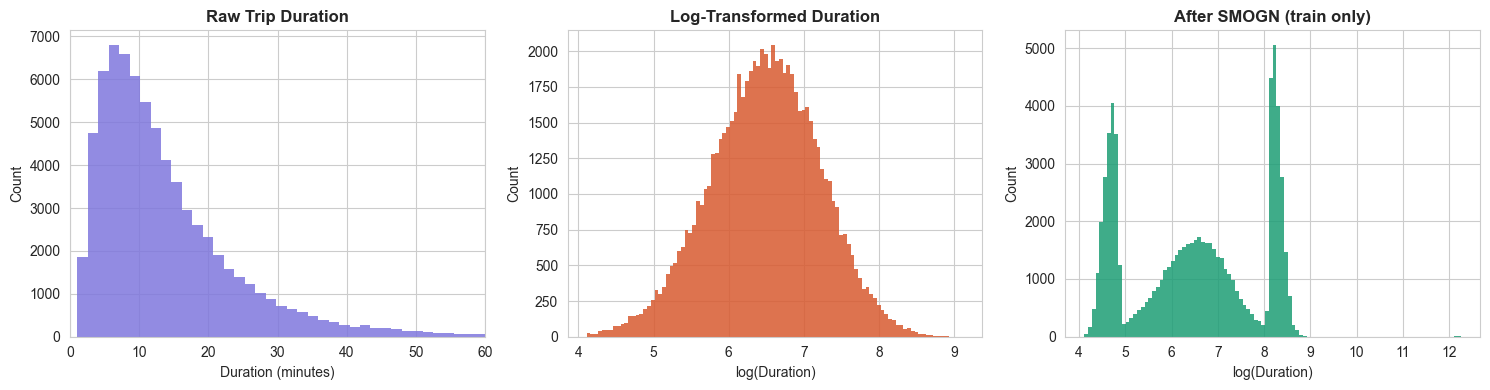

 Saved: plots/viz_0_target_distribution_smogn.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['trip_duration'] / 60, bins=100,
            color='#7F77DD', edgecolor='none', alpha=0.85)
axes[0].set_title('Raw Trip Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 60)

axes[1].hist(df['log_duration'], bins=100,
            color='#D85A30', edgecolor='none', alpha=0.85)
axes[1].set_title('Log-Transformed Duration', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Duration)')
axes[1].set_ylabel('Count')

axes[2].hist(y_train, bins=100,
            color='#1D9E75', edgecolor='none', alpha=0.85)
axes[2].set_title('After SMOGN (train only)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('log(Duration)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plots/viz_0_target_distribution_smogn.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/viz_0_target_distribution_smogn.png')

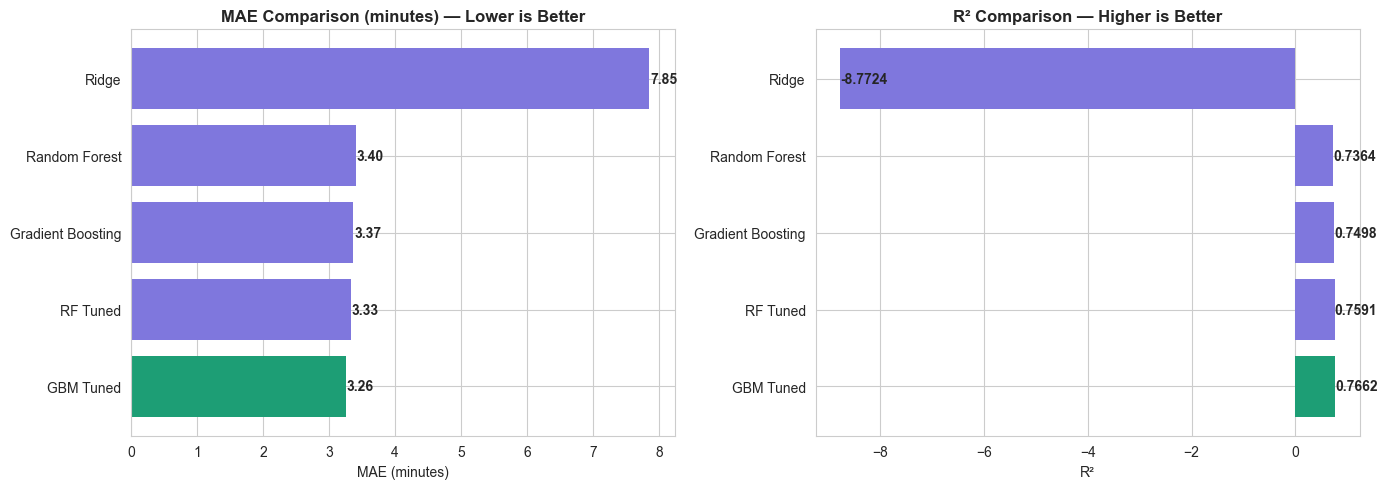

 Saved: plots/viz_1_model_comparison.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = comparison_df['Model'].tolist()
maes        = comparison_df['MAE (minutes)'].tolist()
r2s         = comparison_df['R²'].tolist()
colors      = ['#1D9E75' if m == best_model_name else '#7F77DD' for m in model_names]

axes[0].barh(model_names, maes, color=colors, edgecolor='none')
axes[0].set_title('MAE Comparison (minutes) — Lower is Better',
                    fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE (minutes)')
for i, v in enumerate(maes):
    axes[0].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

axes[1].barh(model_names, r2s, color=colors, edgecolor='none')
axes[1].set_title('R² Comparison — Higher is Better',
                    fontsize=12, fontweight='bold')
axes[1].set_xlabel('R²')
for i, v in enumerate(r2s):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/viz_1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/viz_1_model_comparison.png')

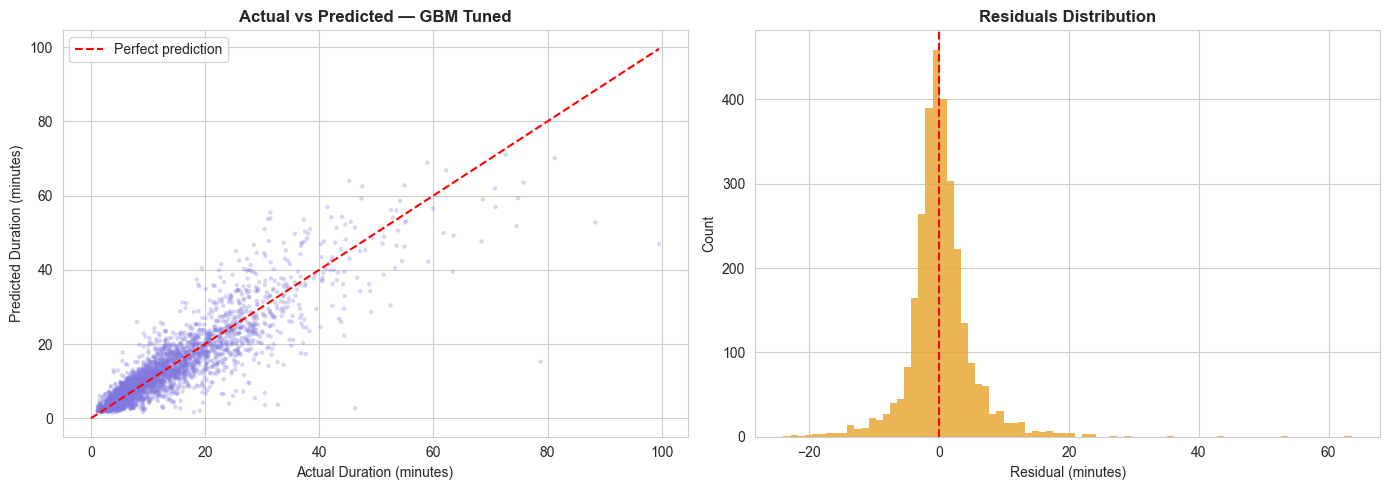

 Saved: plots/viz_2_actual_vs_predicted.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx  = np.random.choice(len(y_test_sec), size=min(3000, len(y_test_sec)), replace=False)
actual_min  = y_test_sec[sample_idx] / 60
pred_min    = best_preds[sample_idx] / 60
max_val     = max(actual_min.max(), pred_min.max())

axes[0].scatter(actual_min, pred_min,
                alpha=0.3, s=10, color='#7F77DD', edgecolors='none')
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}',
                    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Duration (minutes)')
axes[0].set_ylabel('Predicted Duration (minutes)')
axes[0].legend()

residuals = actual_min - pred_min
axes[1].hist(residuals, bins=80, color='#E8A838', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residuals Distribution',
                    fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (minutes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plots/viz_2_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/viz_2_actual_vs_predicted.png')

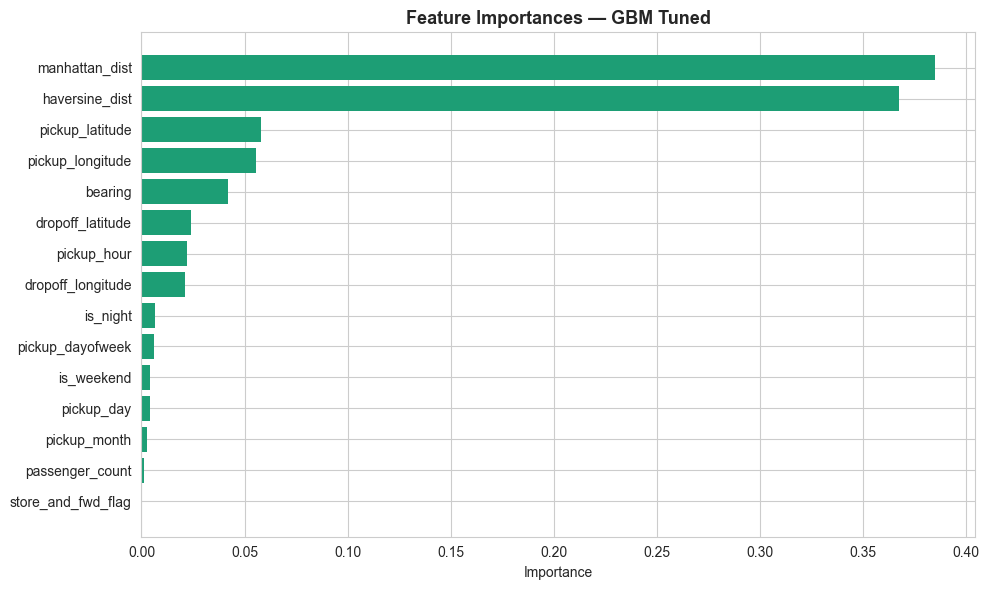

 Saved: plots/viz_3_feature_importance.png


In [33]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp_df = pd.DataFrame({
        'Feature'   : selected_features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
            color='#1D9E75', edgecolor='none')
    plt.title(f'Feature Importances — {best_model_name}',
             fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plots/viz_3_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: plots/viz_3_feature_importance.png')
else:
    print(' Best model does not have feature_importances_ (Ridge Regression)')